# Data Preprocessing and Feature Engineering in Machine Learning

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [20]:
#loading the dataset
data = pd.read_csv("adult_with_headers (1).csv")
data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


#### 1.Handle missing values as per the best practices (imputation, removal, etc.).

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [22]:
data.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [23]:
data.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [24]:
data.replace(' ?', np.nan, inplace=True)

data.isnull().sum()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col].fillna(data[col].mode()[0], inplace=True)

C:\Users\h238p\AppData\Local\Temp\ipykernel_18040\273632333.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [25]:
data.duplicated().sum()

np.int64(24)

In [26]:
data.drop_duplicates(inplace = True)

In [27]:
data.duplicated().sum()

np.int64(0)

In [28]:
data.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

In [29]:
num_cols = data.select_dtypes(include=['int64','float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

print(num_cols)
print(cat_cols)

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')
Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')


#### ●Apply scaling techniques to numerical features:


#### a.Standard Scaling  

In [30]:
standard_scaler = StandardScaler()

data_standard = data.copy()

data_standard[num_cols] = standard_scaler.fit_transform(data_standard[num_cols])

data_standard.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.030390,State-gov,-1.063569,Bachelors,1.134777,Never-married,Adm-clerical,Not-in-family,White,Male,0.148292,-0.216743,-0.035664,United-States,<=50K
1,0.836973,Self-emp-not-inc,-1.008668,Bachelors,1.134777,Married-civ-spouse,Exec-managerial,Husband,White,Male,-0.145975,-0.216743,-2.222483,United-States,<=50K
2,-0.042936,Private,0.245040,HS-grad,-0.420679,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.145975,-0.216743,-0.035664,United-States,<=50K
3,1.056950,Private,0.425752,11th,-1.198407,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,-0.145975,-0.216743,-0.035664,United-States,<=50K
4,-0.776193,Private,1.408066,Bachelors,1.134777,Married-civ-spouse,Prof-specialty,Wife,Black,Female,-0.145975,-0.216743,-0.035664,Cuba,<=50K


#### b. Min-Max Scaling

In [31]:
minmax_scaler = MinMaxScaler()

data_minmax = data.copy()

data_minmax[num_cols] = minmax_scaler.fit_transform(data_minmax[num_cols])

data_minmax.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.301370,State-gov,0.044302,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.02174,0.0,0.397959,United-States,<=50K
1,0.452055,Self-emp-not-inc,0.048238,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.00000,0.0,0.122449,United-States,<=50K
2,0.287671,Private,0.138113,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.00000,0.0,0.397959,United-States,<=50K
3,0.493151,Private,0.151068,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.00000,0.0,0.397959,United-States,<=50K
4,0.150685,Private,0.221488,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.00000,0.0,0.397959,Cuba,<=50K


#### ●Discuss the scenarios where each scaling technique is preferred and why.

##### Standard Scaling
##### Standard Scaling transforms data so that it has a mean of 0 and a standard deviation of 1.

##### **Preferred when:**
##### - Data follows a normal distribution.
##### - Algorithms are distance-based (KNN, SVM, PCA, Logistic Regression).
##### Presence of outliers is acceptable.

##### Min-Max Scaling
##### Min-Max Scaling transforms values to a fixed range, usually between 0 and 1.

##### **Preferred when:**
##### - Data does not follow a normal distribution.
##### - Features need to be bounded within a specific range.
##### - Algorithms such as Neural Networks benefit from normalized inputs.

##### Conclusion
##### Standard Scaling is suitable for normally distributed data, whereas Min-Max Scaling is preferred when features need to be scaled to a fixed range.

#### 2. Encoding Techniques:

In [32]:
small_cat_cols = [col for col in cat_cols if data[col].nunique() < 5]
small_cat_cols

['sex', 'income']

In [33]:
data = pd.get_dummies(data, columns = small_cat_cols)

In [34]:
cat_cols = data.select_dtypes(include=['object']).columns

large_cat_cols = [col for col in cat_cols if data[col].nunique() > 5]

large_cat_cols

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'native_country']

In [35]:
le = LabelEncoder()

for col in large_cat_cols:
    data[col] = le.fit_transform(data[col])


### Pros and Cons of One-Hot Encoding vs Lable Encoding
#### One-Hot Encoding 
##### Pros
##### Does not introduce any false ordinal (ranking) relationship between categories.
##### Suitable for nominal categorical variables (categories with no natural order).
##### Performs well with linear models and distance-based algorithms (e.g., Linear Regression, Logistic Regression, KNN, SVM).
##### Easy for models to interpret since each category is represented independently.
##### Cons
##### Increases the number of features, leading to high dimensionality.
##### Produces a sparse matrix when there are many categories.
##### Requires more memory and computational resources.
##### Can slow down model training, especially with high-cardinality features.

#### Lable Encoding
##### Pros
##### Memory efficient because it uses only one column per feature.
##### Simple and fast to implement.
##### Suitable for high-cardinality categorical variables.
##### Works well with tree-based models (Decision Trees, Random Forest, XGBoost) since they do not rely on numerical order.
##### Cons
##### Introduces a false ordinal relationship between categories.
##### Can mislead linear and distance-based models, which may interpret larger integers as having greater importance.
##### May reduce model performance if the encoded order has no real meaning.
##### Not suitable for nominal features when using algorithms sensitive to numerical values.

#### Why we used this split rule (< 5 vs >= 5 categories):
##### One-Hot Encoding is safe and effective for columns with very few categories since it won't blow up the dataset's width. For columns with many categories (like native_country with ~40 categories), One-Hot Encoding would create 40 new columns — Label Encoding keeps the dataset compact, which works fine especially with tree-based models that don't assume ordinal relationships. give the pros and cons in points

## 3: Feature Engineering

In [36]:
#feature 1
data['Capital_Total'] = data['capital_gain']+data['capital_loss']

### Feature 1: Capital_Total

##### Capital_Total is created by combining capital_gain and capital_loss.

##### Formula:

##### Capital_Total = capital_gain - capital_loss

#### Rationale:
##### - Provides the overall capital impact of an individual.
##### - Reduces the need for the model to interpret two separate but related variables.
##### - May improve prediction of income level.

In [37]:
#feature 2
data['Hours_Age_Ratio'] = data['hours_per_week']/ (data['age']+1)

### Feature 2: Hours_Age_Ratio

##### Hours_Age_Ratio = hours_per_week / age

#### Rationale:
##### - Represents work intensity relative to age.
##### - Helps identify individuals who work significantly more hours for their age group.
##### - May provide additional information useful for income prediction.

#### Log Transformation

In [39]:
#checking skewness
data['capital_gain'].skew()

np.float64(11.949402833551465)

In [40]:
#Applying Log Transformation
data['capital_gain_log'] = np.log1p(data['capital_gain'])

## Log Transformation of Skewed Feature

##### The feature capital_gain was highly right-skewed.
##### A log transformation using log1p() was applied:
##### log1p(x) = log(1 + x)

### Benefits
##### - Reduces skewness.
##### - Makes the distribution closer to normal.
##### - Improves the performance of many machine learning algorithms.
##### - Reduces the influence of extreme values.

##### The transformed feature is named capital_gain_log.

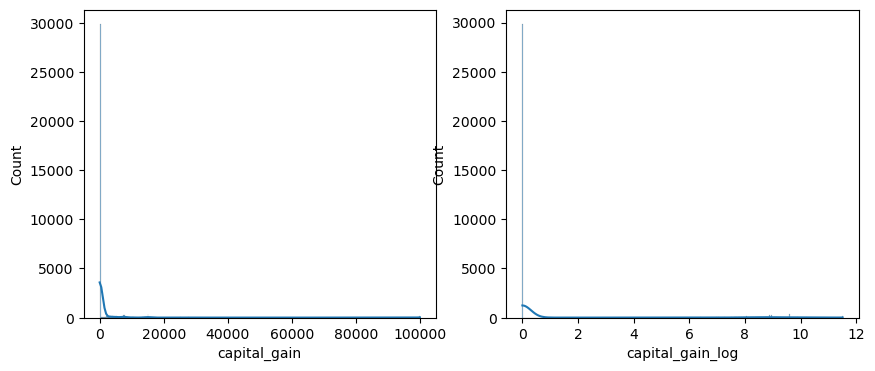

In [41]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(data['capital_gain'], kde=True)

plt.subplot(1,2,2)
sns.histplot(data['capital_gain_log'], kde=True)

plt.show()

##### Justification:  The capital-gain feature is highly right-skewed. Applying log transformation reduces skewness, minimizes the effect of extreme values, and improves the distribution of the data, making it more suitable for machine learning models.